# Socioeconomic data on the map

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from pathlib import Path

DATA = Path('../data')

socio          = pd.read_csv(DATA / 'socioeconomic.csv')
municipalities = gpd.read_file(DATA / 'municipalities.geojson')
enriched       = pd.read_csv(DATA / 'features.csv')


socio.head()

,municipality_id,population,gdp_per_capita,infrastructure_density
0,MUN_000,8506,35988,7.44
1,MUN_001,756,9764,1.64
2,MUN_002,18974,25477,14.99
3,MUN_003,26716,15813,6.64
4,MUN_004,200,17597,0.82


In [3]:
gdf = municipalities.merge(socio, on='municipality_id', how='left')
gdf.head()

,municipality_id,geometry,population,gdp_per_capita,infrastructure_density
0,MUN_000,"POLYGON ((15.12363 43.56045, 14.99213 43.66491...",8506,35988,7.44
1,MUN_001,"POLYGON ((10.97089 37.15282, 11.32201 37.40756...",756,9764,1.64
2,MUN_002,"POLYGON ((16.50393 40.93979, 15.89771 40.86407...",18974,25477,14.99
3,MUN_003,"POLYGON ((14.13883 40.86548, 13.94281 41.10355...",26716,15813,6.64
4,MUN_004,"POLYGON ((6.00000 43.91757, 6.00000 44.49096, ...",200,17597,0.82


## Choropleth maps by municipality

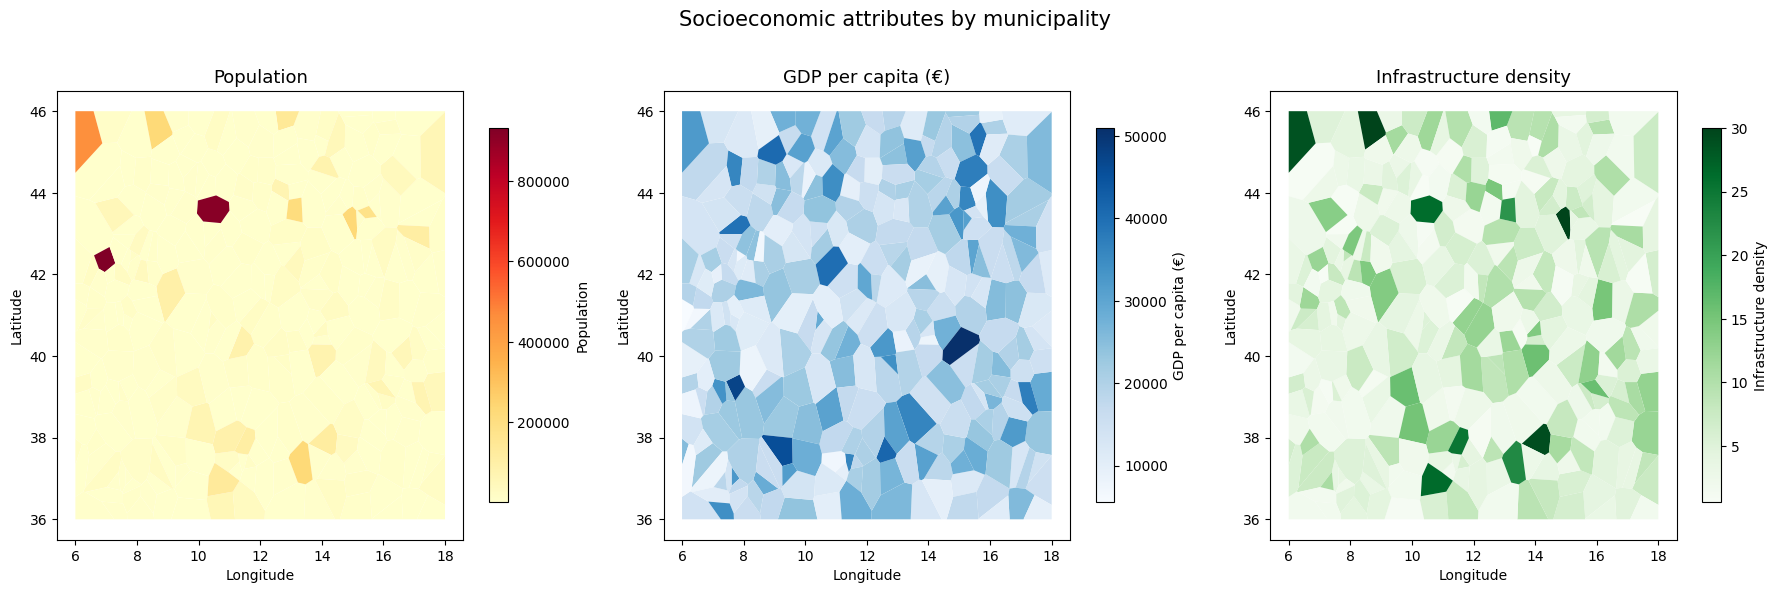

In [4]:
columns = ['population', 'gdp_per_capita', 'infrastructure_density']
titles  = ['Population', 'GDP per capita (€)', 'Infrastructure density']
cmaps   = ['YlOrRd',         'Blues',             'Greens']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, col, title, cmap in zip(axes, columns, titles, cmaps):
    gdf.plot(column=col, ax=ax, cmap=cmap, legend=True,
             legend_kwds={'shrink': 0.7, 'label': title})
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.suptitle('Socioeconomic attributes by municipality', fontsize=15)
plt.tight_layout()
plt.show()

## Pipeline check: fire events coloured by socioeconomic attributes

/var/folders/gy/lfvz5g2n20sg188jjt5spxc40000gn/T/ipykernel_90752/4290861699.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = cm.get_cmap(cmap)(norm(enriched[col]))


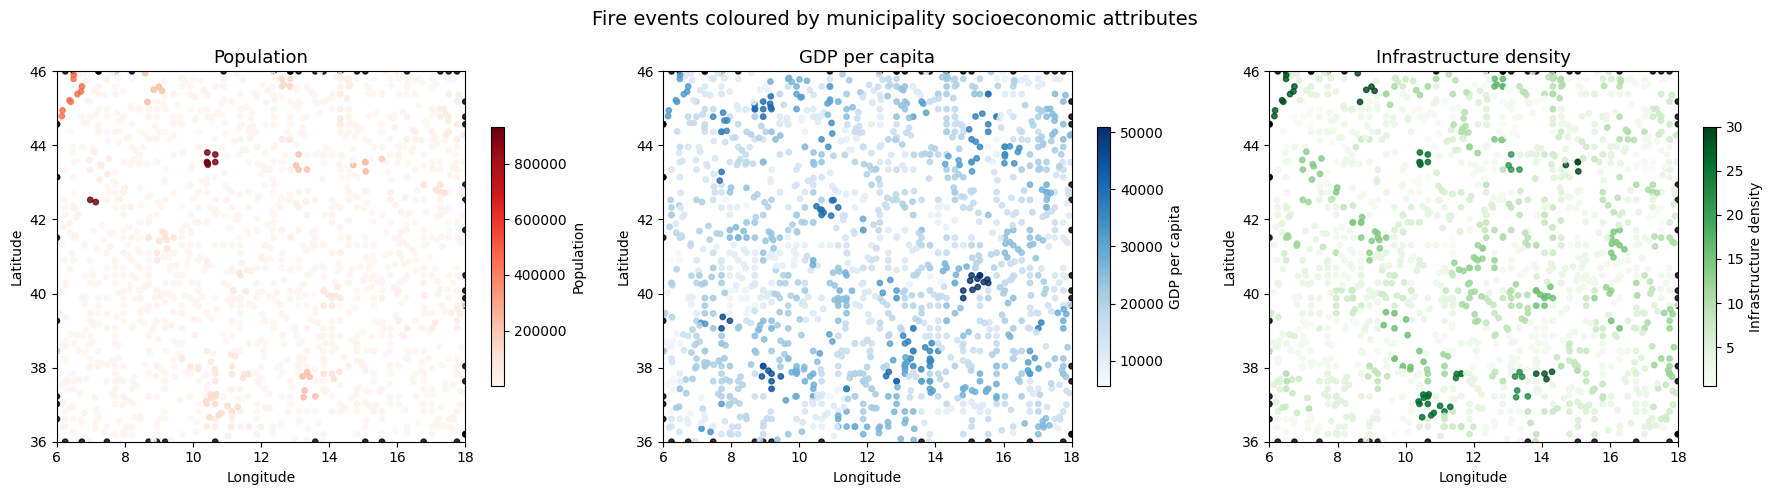

In [5]:
columns = ['population', 'gdp_per_capita', 'infrastructure_density']
cmaps   = ['Reds',           'Blues',          'Greens']
titles  = ['Population', 'GDP per capita', 'Infrastructure density']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, cmap, title in zip(axes, columns, cmaps, titles):
    norm   = mcolors.Normalize(vmin=enriched[col].min(), vmax=enriched[col].max())
    colors = cm.get_cmap(cmap)(norm(enriched[col]))
    ax.scatter(enriched['lon'], enriched['lat'], c=colors, s=15, alpha=0.8)
    plt.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, shrink=0.7, label=title)
    ax.set_xlim(6, 18)
    ax.set_ylim(36, 46)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.suptitle('Fire events coloured by municipality socioeconomic attributes', fontsize=14)
plt.tight_layout()
plt.show()

**Note:** the maps look noisy because each municipality was assigned an independent random value. A more realistic synthetic dataset would apply spatial smoothing before assigning values to municipalities, especially for population.

## Pipeline check: fire vs no-fire points on the map

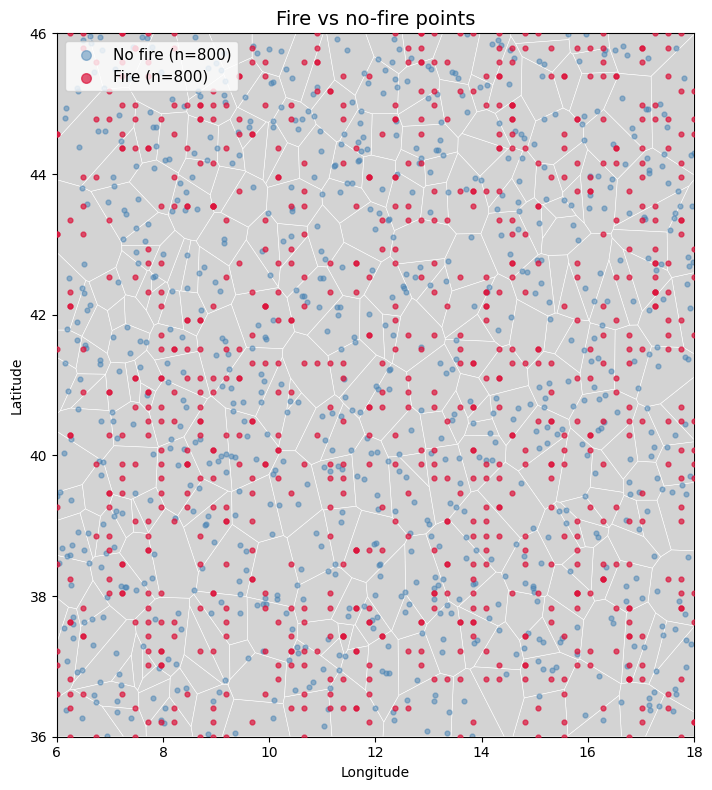

In [6]:
fires    = enriched[enriched['target'] == 1]
no_fires = enriched[enriched['target'] == 0]

fig, ax = plt.subplots(figsize=(10, 8))

gdf.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.4)

ax.scatter(no_fires['lon'], no_fires['lat'], s=12, alpha=0.5, color='steelblue', label=f'No fire (n={len(no_fires)})', zorder=2)
ax.scatter(fires['lon'],    fires['lat'],    s=12, alpha=0.7, color='crimson',   label=f'Fire (n={len(fires)})',    zorder=3)

ax.set_xlim(6, 18)
ax.set_ylim(36, 46)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Fire vs no-fire points', fontsize=14)
ax.legend(markerscale=2, fontsize=11)

plt.tight_layout()
plt.show()